#### Outline

- [Business Understanding](#Business-Understanding)
- [Data Understanding](#Data-Understanding)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)    
- [Data Pre-processing](#Data-Pre-processing)
- [Model Deployment](#Model-Deployment)
- [Model Interpretation](#Model-Interpretation)
- [Model Deployment](#Model-Deployment)
- [Interpretation and Recommendation](#Interpretation-and-Recommendation)

#### Business Understanding

Step 1: Business Understanding

In [ ]:

# STEP 1: BUSINESS UNDERSTANDING
# Construction Cost Overrun Prediction

# BUSINESS PROBLEM

# Construction projects frequently exceed their planned budgets due to
# factors such as design changes, labour shortages, weather conditions,
# material price inflation, and project delays.

# The goal of this project is to build a machine learning model capable
# of predicting construction cost overruns and identifying the factors
# that contribute most to budget increases.

# BUSINESS OBJECTIVES

# 1. Predict project cost overruns before project completion.
# 2. Identify major drivers of construction cost overruns.
# 3. Support better budgeting and project planning.
# 4. Improve decision-making using predictive analytics.



Step 2: Import Libraries

In [1]:

# STEP 2: IMPORT LIBRARIES

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')



Step 3: Set Display Options

In [3]:

# STEP 3: SET DISPLAY OPTIONS

# Display all columns
pd.set_option('display.max_columns', None)

# Display wider tables
pd.set_option('display.width', 1000)

# Display numbers with 2 decimal places
pd.options.display.float_format = '{:,.2f}'.format


#### Data Understanding

Step 4: Load Dataset

In [4]:

# STEP 4: LOAD DATASET


# Load dataset if in the Python Environment
#df = pd.read_csv("construction_cost_overrun_synthetic(4).csv")


# If your notebook is in another folder, use:
df = pd.read_csv(r"C:\Users\Emeka\Desktop\constr_overun\construction_cost_overrun_synthetic.csv")

Step 5: Data Inspection

In [5]:

# STEP 5: DATA INSPECTION

# Display first five rows
df.head()


,Project_ID,Project_Type,Location_Type,Planned_Budget_Millions,Actual_Cost_Millions,Cost_Overrun_Millions,Overrun_Percentage,Planned_Duration_Months,Actual_Duration_Months,Delay_Months,Primary_Cause_of_Overrun
0,PRJ-0001,Commercial,Suburban,16.37,17.78,1.41,8.64,21,32,11,Site Conditions
1,PRJ-0002,Industrial,Urban,135.48,146.32,10.84,8.00,11,12,1,Labor Shortage
2,PRJ-0003,Infrastructure,Urban,76.28,101.99,25.71,33.70,13,22,9,Weather Delays
3,PRJ-0004,Commercial,Suburban,124.14,127.34,3.20,2.58,30,32,2,Labor Shortage
4,PRJ-0005,Residential,Suburban,48.69,52.76,4.07,8.36,23,28,5,Design Errors


In [6]:
# Print data shape, number of columns and rows

print(df.shape)

(200, 11)


In [ ]:
# We have 200 rows and 11 columns

In [7]:
# List Column names

print("\nColumn Names")
print(df.columns.tolist())



Column Names
['Project_ID', 'Project_Type', 'Location_Type', 'Planned_Budget_Millions', 'Actual_Cost_Millions', 'Cost_Overrun_Millions', 'Overrun_Percentage', 'Planned_Duration_Months', 'Actual_Duration_Months', 'Delay_Months', 'Primary_Cause_of_Overrun']


In [8]:
# List Data types
print("\nData Types")
display(df.dtypes)



Data Types


Project_ID                      str
Project_Type                    str
Location_Type                   str
Planned_Budget_Millions     float64
Actual_Cost_Millions        float64
Cost_Overrun_Millions       float64
Overrun_Percentage          float64
Planned_Duration_Months       int64
Actual_Duration_Months        int64
Delay_Months                  int64
Primary_Cause_of_Overrun        str
dtype: object

In [9]:
# List dataset information

print("\nDataset Information")
df.info()



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Project_ID                200 non-null    str    
 1   Project_Type              200 non-null    str    
 2   Location_Type             200 non-null    str    
 3   Planned_Budget_Millions   200 non-null    float64
 4   Actual_Cost_Millions      200 non-null    float64
 5   Cost_Overrun_Millions     200 non-null    float64
 6   Overrun_Percentage        200 non-null    float64
 7   Planned_Duration_Months   200 non-null    int64  
 8   Actual_Duration_Months    200 non-null    int64  
 9   Delay_Months              200 non-null    int64  
 10  Primary_Cause_of_Overrun  200 non-null    str    
dtypes: float64(4), int64(3), str(4)
memory usage: 17.3 KB


In [ ]:
# The above two information displayed, the dataset type is normal and there is not missing values. However, we still need to confirm

In [10]:
# Missing values

print("\nMissing Values")
display(df.isnull().sum())



Missing Values


Project_ID                  0
Project_Type                0
Location_Type               0
Planned_Budget_Millions     0
Actual_Cost_Millions        0
Cost_Overrun_Millions       0
Overrun_Percentage          0
Planned_Duration_Months     0
Actual_Duration_Months      0
Delay_Months                0
Primary_Cause_of_Overrun    0
dtype: int64

In [11]:
# Duplicate records

print("\nDuplicate Records")
print(df.duplicated().sum())



Duplicate Records
0


In [ ]:
# There are no duplicated records

In [12]:
# Statistical summary

print("\nSummary Statistics")
display(df.describe(include='all'))



Summary Statistics


,Project_ID,Project_Type,Location_Type,Planned_Budget_Millions,Actual_Cost_Millions,Cost_Overrun_Millions,Overrun_Percentage,Planned_Duration_Months,Actual_Duration_Months,Delay_Months,Primary_Cause_of_Overrun
count,200,200,200,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200
unique,200,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,PRJ-0001,Residential,Urban,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weather Delays
freq,1,66,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39
mean,NaN,NaN,NaN,78.58,94.13,15.55,19.41,27.07,33.78,6.71,NaN
std,NaN,NaN,NaN,45.79,56.77,15.63,13.39,12.17,13.18,4.42,NaN
min,NaN,NaN,NaN,2.61,3.01,-7.28,-5.00,6.00,6.00,0.00,NaN
25%,NaN,NaN,NaN,39.07,43.96,3.72,9.69,17.00,24.00,3.00,NaN
50%,NaN,NaN,NaN,79.28,95.84,9.93,17.91,28.00,34.00,7.00,NaN
75%,NaN,NaN,NaN,121.85,142.03,23.68,29.34,38.00,44.25,10.00,NaN


In [ ]:
# Explanation

# 1. Project Types: There are 4 unique project types. Residential is the most frequent category it appears 66 times 
#    out of the 200 projects which is about 33% of the number constructions .
# 2. Locations Type: We have 3 unique location types. Urban location is more because of population growth, it has 113 out of 200 location sites
#    which is 56.5% of the total construction location sites.
#   
#  Financial Metrics ($ Millions)
# 1. Planned Budget  
#    Mean Planned Budget: $78.58M (Median = $79.28M. The difference is not much and can be tolerated)
#    Minimum Planned Budget: $2.61M 
#    Maximum Planned Budget: $149.96M
# 2. Actual Cost
#    Mean Actual Cost: $94.13M (Median = $95.84. The difference is not much)
#    Minimum Actual Cost: $3.01M
# 3. Maximum Actual Cost: $195.46M
#
# Cost Overrun
# 1. Mean Overrun: $15.55M
# 2. Minimum Overrun: -$7.28M (It can as under budget with $7.28M)
# 3. Maximum Overrun: +$65.87M (It occurs in the case of high cost escalation)

# Spread
# Standard deviation: $15.63M ( Which shows high variance in controlling budget across projects).
# Skewness: The overrun is right-skew because the mean value($15.55M) is far more than median($9.93M). 
# Which shows that some projects cost were more than necessary.

# Planned Duration(Months): The mean (27.07) and the median(28). The difference is not much
# Actual Duration(Months): The mean (33.78) and the median(34). The difference is not much
 
# Average Delay Months: 33.78 - 27.07 = 6.71 per project

Step:6 Exploratory Data Analysis

In [13]:
# STEP 6: EXPLORATORY DATA ANALYSIS (EDA)

# Dataset dimensions
print(f"\nNumber of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

# Number of numerical and categorical variables
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nNumerical Variables ({len(numerical_cols)}):")
print(list(numerical_cols))

print(f"\nCategorical Variables ({len(categorical_cols)}):")
print(list(categorical_cols))

# Unique values in categorical columns
print("\nUnique Values in Categorical Variables")
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())



Number of Rows: 200
Number of Columns: 11

Numerical Variables (7):
['Planned_Budget_Millions', 'Actual_Cost_Millions', 'Cost_Overrun_Millions', 'Overrun_Percentage', 'Planned_Duration_Months', 'Actual_Duration_Months', 'Delay_Months']

Categorical Variables (4):
['Project_ID', 'Project_Type', 'Location_Type', 'Primary_Cause_of_Overrun']

Unique Values in Categorical Variables

Project_ID
Project_ID
PRJ-0001    1
PRJ-0002    1
PRJ-0003    1
PRJ-0004    1
PRJ-0005    1
           ..
PRJ-0196    1
PRJ-0197    1
PRJ-0198    1
PRJ-0199    1
PRJ-0200    1
Name: count, Length: 200, dtype: int64

Project_Type
Project_Type
Residential       66
Commercial        56
Infrastructure    47
Industrial        31
Name: count, dtype: int64

Location_Type
Location_Type
Urban       113
Suburban     68
Rural        19
Name: count, dtype: int64

Primary_Cause_of_Overrun
Primary_Cause_of_Overrun
Weather Delays               39
Design Errors                36
Site Conditions              34
Labor Shortage  

In [ ]:
# From the dataset it was obsevered from the Primary_Cause_of_Overrun column that Labor shortage counted 33 times, 
# Scope Creep counted 32 times and Material Price Ecalation counted for 26 times

Step 7: Missing Values & Duplicated Analysis

In [14]:

# STEP 7: MISSING VALUES & DUPLICATE ANALYSIS


# Missing values
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing = missing.sort_values(by='Missing Values', ascending=False)

print("\nMissing Value Summary")
display(missing)

# Duplicate records
duplicates = df.duplicated().sum()

print(f"\nNumber of Duplicate Records: {duplicates}")

# Remove duplicates if present
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed successfully.")
else:
    print("No duplicate records found.")



Missing Value Summary


,Missing Values,Percentage
Project_ID,0,0.00
Project_Type,0,0.00
Location_Type,0,0.00
Planned_Budget_Millions,0,0.00
Actual_Cost_Millions,0,0.00
Cost_Overrun_Millions,0,0.00
Overrun_Percentage,0,0.00
Planned_Duration_Months,0,0.00
Actual_Duration_Months,0,0.00
Delay_Months,0,0.00



Number of Duplicate Records: 0
No duplicate records found.


Step 8: Descriptive Statistics

In [ ]:

# STEP 8: DESCRIPTIVE STATISTICS

# The code will help to summary and segregate the dataset into important features: Numerical and Categorical data, 
# the Median, Variance, Standard Deviation and Mean

# Numerical summary
display(df.describe())

# Categorical summary
display(df.describe(include='object'))

# Median of numerical variables
print("\nMedian Values")
display(df.median(numeric_only=True))

# Mean of numerical variables
print("\nMean Values")
display(df.mean(numeric_only=True))

# Variance
print("\nVariance")
display(df.var(numeric_only=True))

# Standard Deviation
print("\nStandard Deviation")
display(df.std(numeric_only=True))


,Planned_Budget_Millions,Actual_Cost_Millions,Cost_Overrun_Millions,Overrun_Percentage,Planned_Duration_Months,Actual_Duration_Months,Delay_Months
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,78.58,94.13,15.55,19.41,27.07,33.78,6.71
std,45.79,56.77,15.63,13.39,12.17,13.18,4.42
min,2.61,3.01,-7.28,-5.00,6.00,6.00,0.00
25%,39.07,43.96,3.72,9.69,17.00,24.00,3.00
50%,79.28,95.84,9.93,17.91,28.00,34.00,7.00
75%,121.85,142.03,23.68,29.34,38.00,44.25,10.00
max,149.96,195.46,65.87,56.35,47.00,60.00,18.00


,Project_ID,Project_Type,Location_Type,Primary_Cause_of_Overrun
count,200,200,200,200
unique,200,4,3,6
top,PRJ-0001,Residential,Urban,Weather Delays
freq,1,66,113,39



Median Values


Planned_Budget_Millions   79.28
Actual_Cost_Millions      95.84
Cost_Overrun_Millions      9.93
Overrun_Percentage        17.91
Planned_Duration_Months   28.00
Actual_Duration_Months    34.00
Delay_Months               7.00
dtype: float64


Mean Values


Planned_Budget_Millions   78.58
Actual_Cost_Millions      94.13
Cost_Overrun_Millions     15.55
Overrun_Percentage        19.41
Planned_Duration_Months   27.07
Actual_Duration_Months    33.78
Delay_Months               6.71
dtype: float64


Variance


Planned_Budget_Millions   2,096.63
Actual_Cost_Millions      3,223.18
Cost_Overrun_Millions       244.20
Overrun_Percentage          179.24
Planned_Duration_Months     148.06
Actual_Duration_Months      173.78
Delay_Months                 19.57
dtype: float64


Standard Deviation


Planned_Budget_Millions   45.79
Actual_Cost_Millions      56.77
Cost_Overrun_Millions     15.63
Overrun_Percentage        13.39
Planned_Duration_Months   12.17
Actual_Duration_Months    13.18
Delay_Months               4.42
dtype: float64

#### Exploratory Data Analysis

Step 9: Univariate Analysis

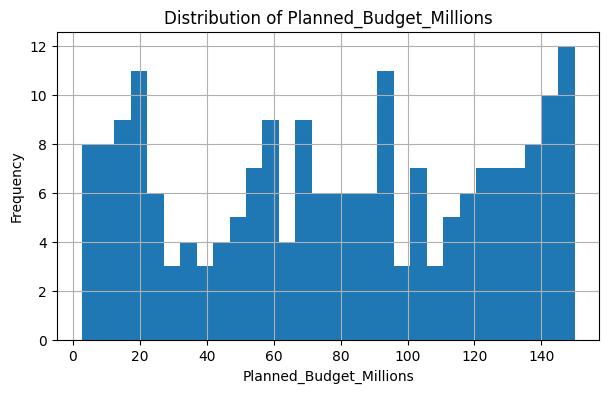

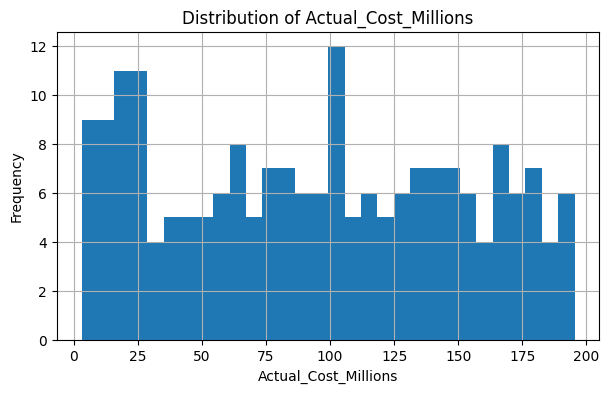

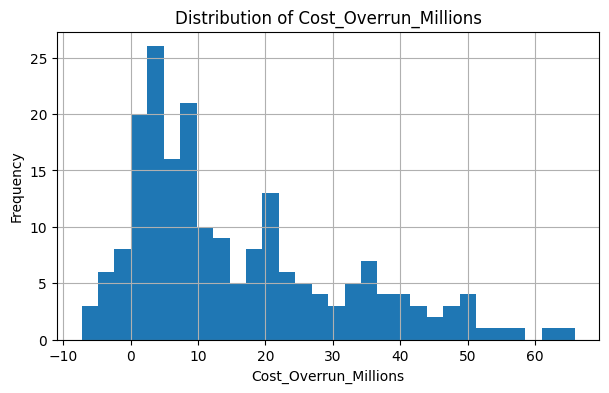

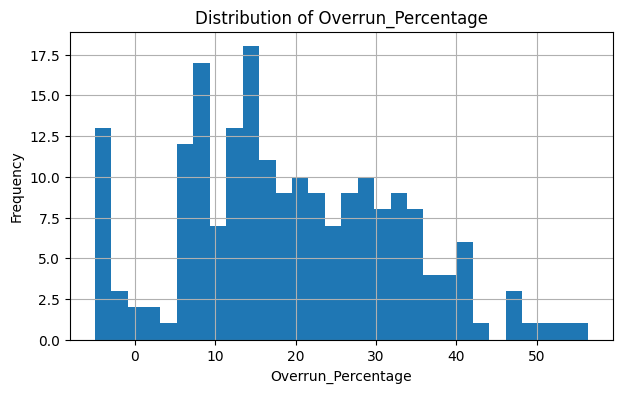

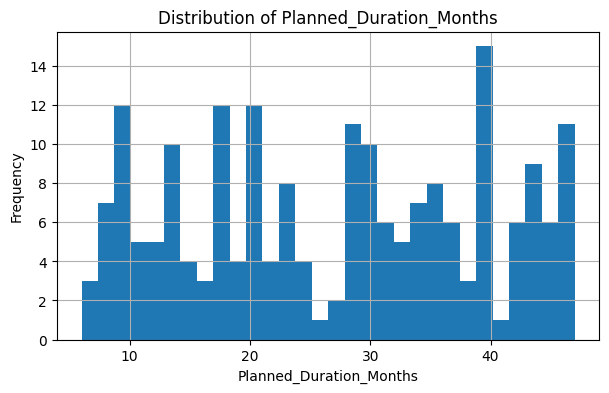

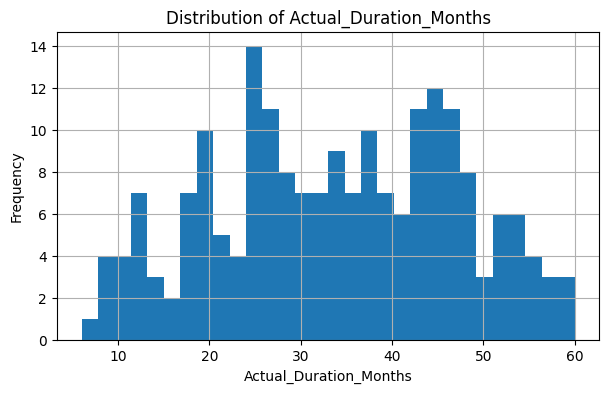

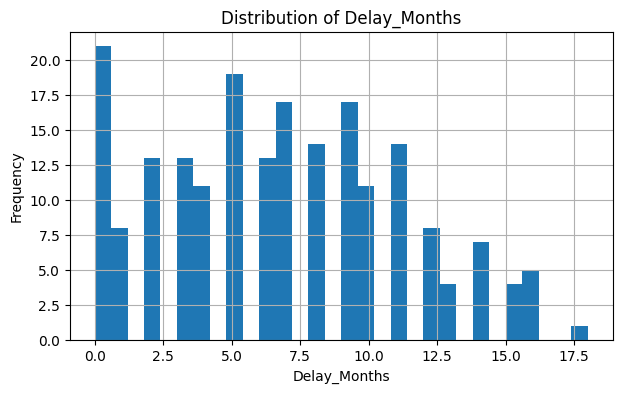

In [16]:

# STEP 9: UNIVARIATE ANALYSIS

# Numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:

    plt.figure(figsize=(7,4))
    plt.hist(df[col], bins=30)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.grid(True)
    plt.show()


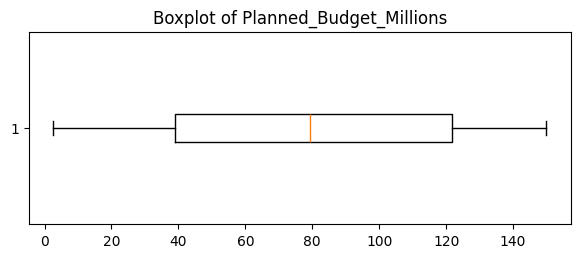

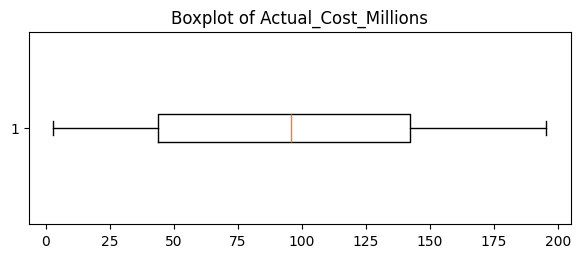

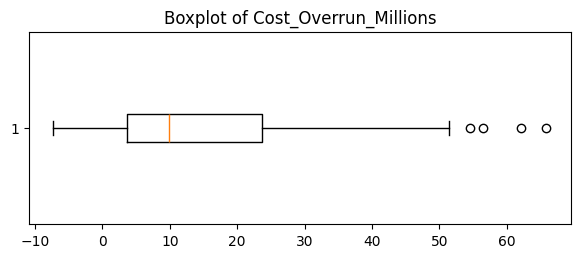

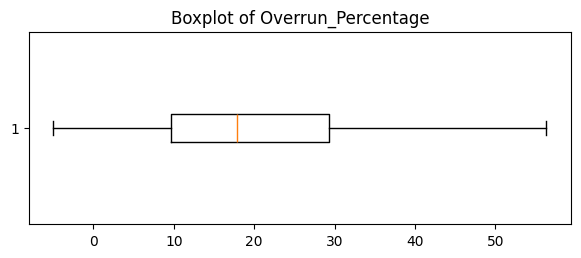

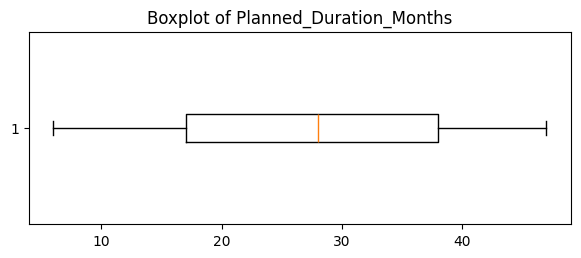

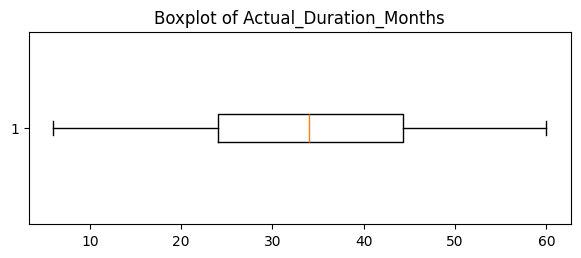

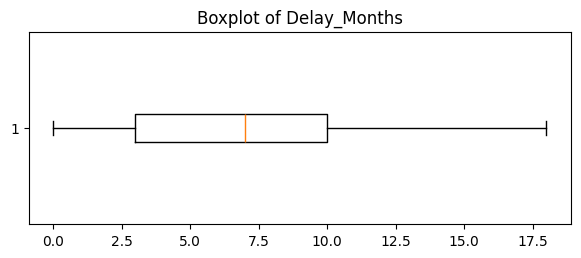

In [17]:

# BOXPLOTS

for col in numeric_columns:

    plt.figure(figsize=(7,2.5))

    plt.boxplot(df[col], vert=False)

    plt.title(f'Boxplot of {col}')

    plt.show()


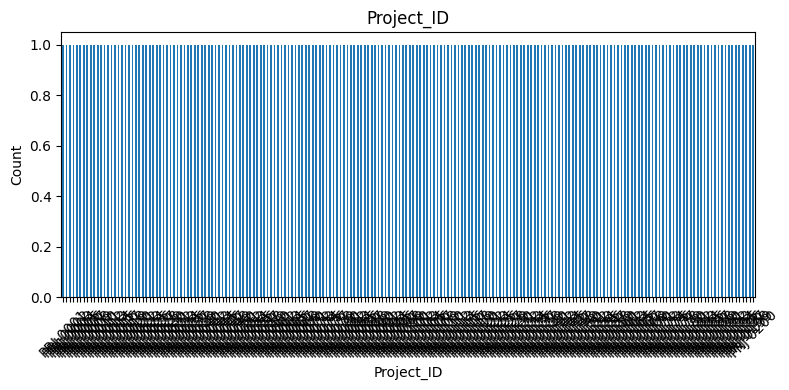

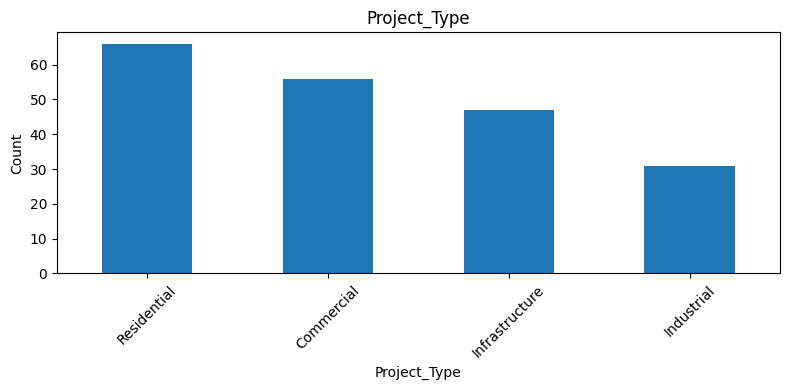

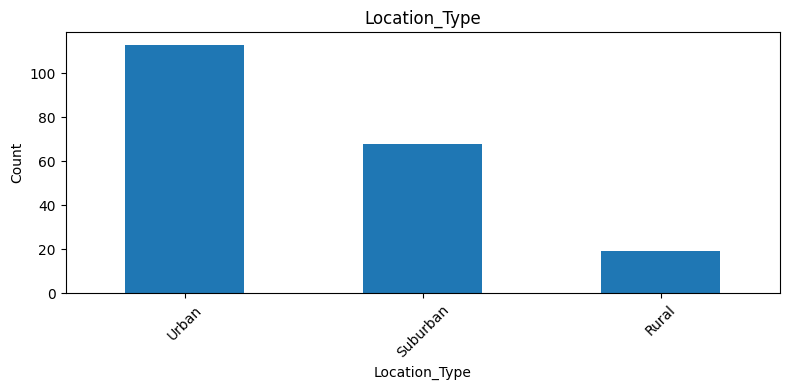

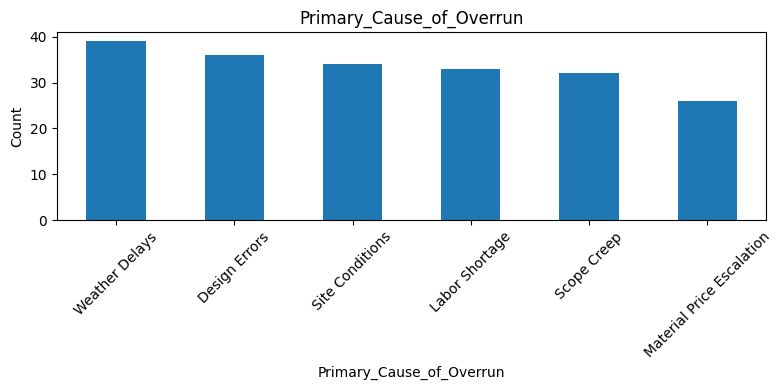

In [18]:

# CATEGORICAL VARIABLES


categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:

    plt.figure(figsize=(8,4))

    df[col].value_counts().plot(kind='bar')

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


Step 10: Correlation Matrix

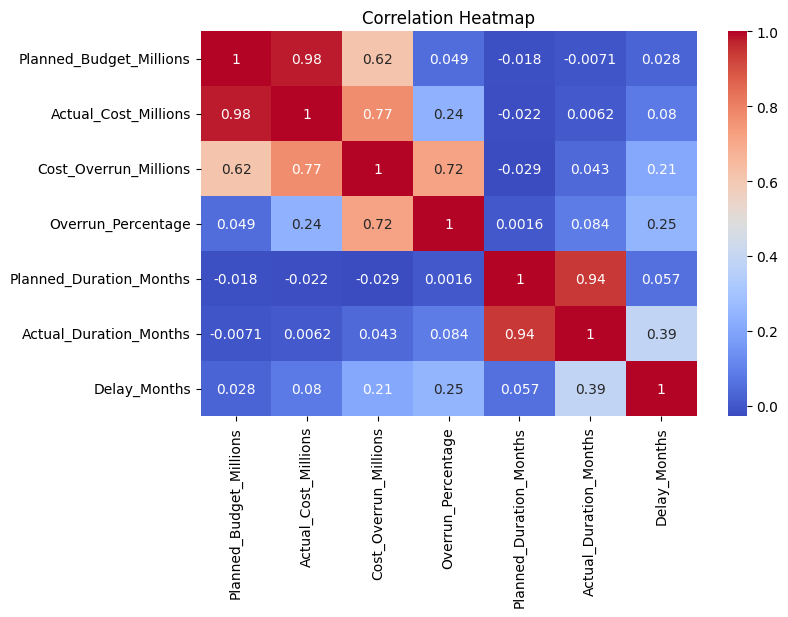

,Planned_Budget_Millions,Actual_Cost_Millions,Cost_Overrun_Millions,Overrun_Percentage,Planned_Duration_Months,Actual_Duration_Months,Delay_Months
Planned_Budget_Millions,1.00,0.98,0.62,0.05,-0.02,-0.01,0.03
Actual_Cost_Millions,0.98,1.00,0.77,0.24,-0.02,0.01,0.08
Cost_Overrun_Millions,0.62,0.77,1.00,0.72,-0.03,0.04,0.21
Overrun_Percentage,0.05,0.24,0.72,1.00,0.00,0.08,0.25
Planned_Duration_Months,-0.02,-0.02,-0.03,0.00,1.00,0.94,0.06
Actual_Duration_Months,-0.01,0.01,0.04,0.08,0.94,1.00,0.39
Delay_Months,0.03,0.08,0.21,0.25,0.06,0.39,1.00


In [ ]:

# STEP 10: CORRELATION MATRIX



plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


correlation = df.select_dtypes(include=['int64','float64']).corr()

display(correlation)

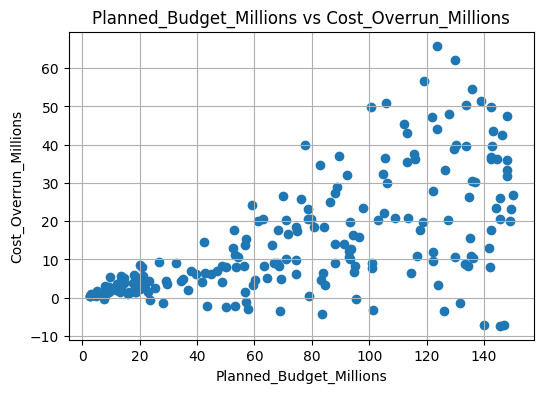

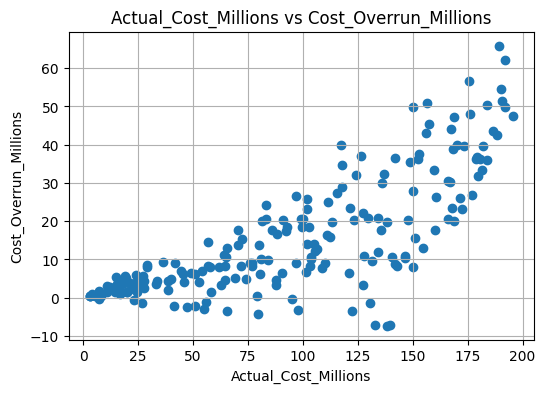

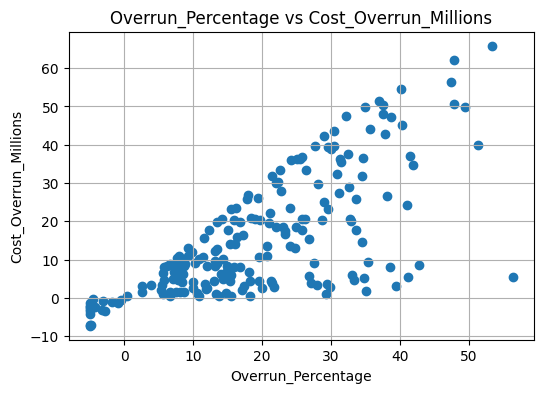

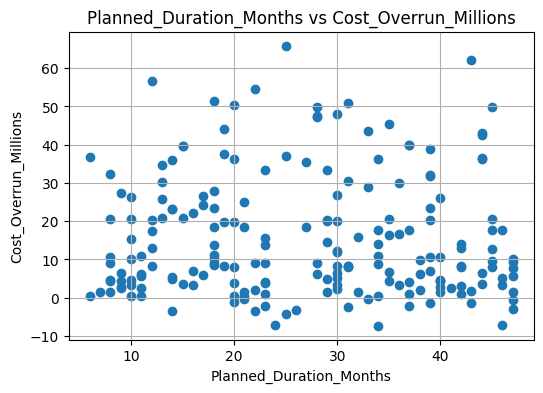

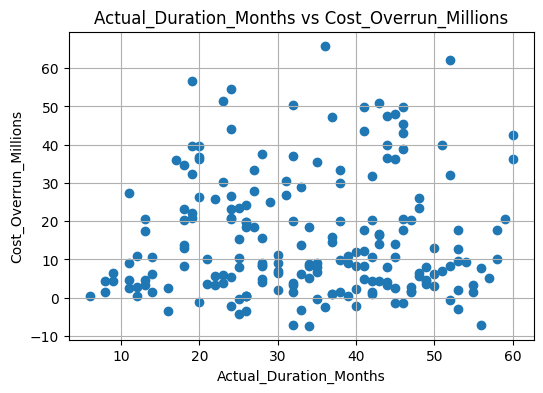

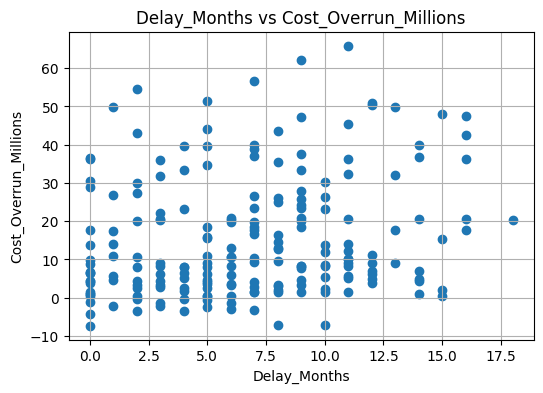

In [21]:

# SCATTER PLOTS


target = "Cost_Overrun_Millions"

predictors = [
    col for col in numeric_columns
    if col != target
]

for col in predictors:

    plt.figure(figsize=(6,4))

    plt.scatter(df[col], df[target])

    plt.xlabel(col)

    plt.ylabel(target)

    plt.title(f'{col} vs {target}')

    plt.grid(True)

    plt.show()


Project_Type
Industrial       12.12
Commercial       14.29
Residential      14.83
Infrastructure   20.33
Name: Cost_Overrun_Millions, dtype: float64

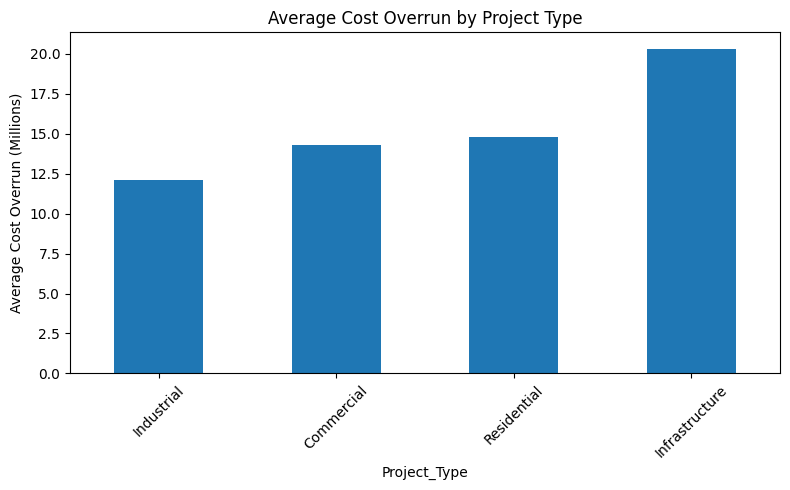

In [22]:

# AVERAGE COST OVERRUN BY PROJECT TYPE


avg_project = df.groupby("Project_Type")[target].mean().sort_values()

display(avg_project)

plt.figure(figsize=(8,5))

avg_project.plot(kind="bar")

plt.title("Average Cost Overrun by Project Type")

plt.ylabel("Average Cost Overrun (Millions)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()



Primary_Cause_of_Overrun
Scope Creep                 12.51
Weather Delays              13.12
Labor Shortage              14.62
Design Errors               17.27
Site Conditions             17.38
Material Price Escalation   19.34
Name: Cost_Overrun_Millions, dtype: float64

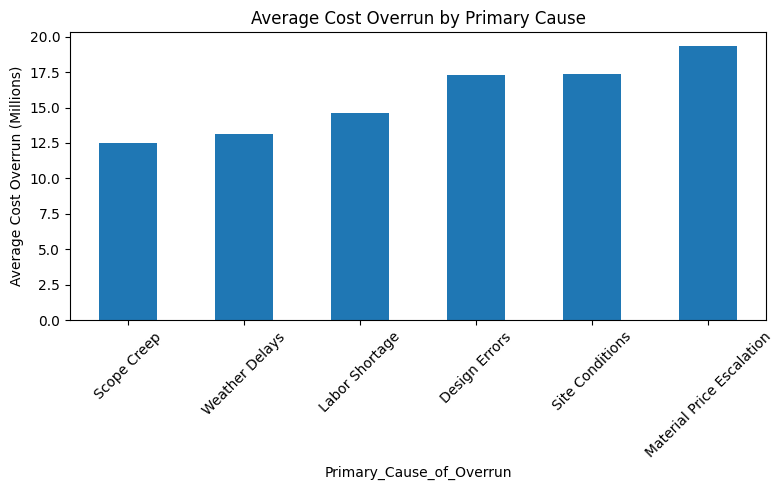

In [23]:

# AVERAGE COST OVERRUN BY PRIMARY CAUSE


avg_cause = df.groupby("Primary_Cause_of_Overrun")[target].mean().sort_values()

display(avg_cause)

plt.figure(figsize=(8,5))

avg_cause.plot(kind="bar")

plt.title("Average Cost Overrun by Primary Cause")

plt.ylabel("Average Cost Overrun (Millions)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


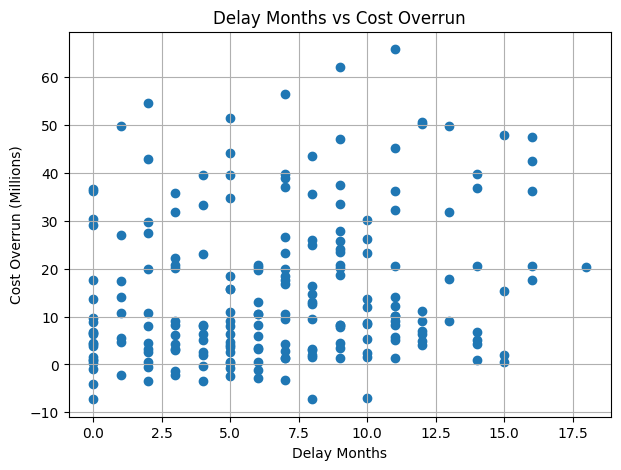

In [24]:

# DELAY MONTHS VS COST OVERRUN


plt.figure(figsize=(7,5))

plt.scatter(df["Delay_Months"], df[target])

plt.xlabel("Delay Months")

plt.ylabel("Cost Overrun (Millions)")

plt.title("Delay Months vs Cost Overrun")

plt.grid(True)

plt.show()


Step 11: Correlation Analysis

In [25]:

# STEP 11: CORRELATION ANALYSIS


# Select numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_df.corr()

print("Correlation Matrix")
display(corr_matrix)

# Correlation with the target variable
target = "Cost_Overrun_Millions"

print(f"\nCorrelation with {target}")

target_corr = corr_matrix[target].sort_values(ascending=False)

display(target_corr)



Correlation Matrix


,Planned_Budget_Millions,Actual_Cost_Millions,Cost_Overrun_Millions,Overrun_Percentage,Planned_Duration_Months,Actual_Duration_Months,Delay_Months
Planned_Budget_Millions,1.00,0.98,0.62,0.05,-0.02,-0.01,0.03
Actual_Cost_Millions,0.98,1.00,0.77,0.24,-0.02,0.01,0.08
Cost_Overrun_Millions,0.62,0.77,1.00,0.72,-0.03,0.04,0.21
Overrun_Percentage,0.05,0.24,0.72,1.00,0.00,0.08,0.25
Planned_Duration_Months,-0.02,-0.02,-0.03,0.00,1.00,0.94,0.06
Actual_Duration_Months,-0.01,0.01,0.04,0.08,0.94,1.00,0.39
Delay_Months,0.03,0.08,0.21,0.25,0.06,0.39,1.00



Correlation with Cost_Overrun_Millions


Cost_Overrun_Millions      1.00
Actual_Cost_Millions       0.77
Overrun_Percentage         0.72
Planned_Budget_Millions    0.62
Delay_Months               0.21
Actual_Duration_Months     0.04
Planned_Duration_Months   -0.03
Name: Cost_Overrun_Millions, dtype: float64

#### Data Pre-processing

Step:12 Feature Engineering

In [57]:

# STEP 12: FEATURE ENGINEERING


# Make a copy of the dataset
df_fe = df.copy()

# Drop column identifier before encoding(i just want to check his direction)
df_fe = df.drop(columns=['Project_ID'])

# Budget Utilisation Ratio
df_fe["Budget_Utilisation_Ratio"] = (
    df_fe["Planned_Budget_Millions"] /
    df_fe["Planned_Budget_Millions"].max()
)

# Delay Percentage
df_fe["Delay_Percentage"] = (
    df_fe["Delay_Months"] /
    df_fe["Planned_Duration_Months"]
)

# Schedule Performance Ratio
df_fe["Schedule_Performance_Ratio"] = (
    df_fe["Actual_Duration_Months"] /
    df_fe["Planned_Duration_Months"]
)

print("Feature engineering completed successfully.")

display(df_fe.head())



Feature engineering completed successfully.


,Project_Type,Location_Type,Planned_Budget_Millions,Actual_Cost_Millions,Cost_Overrun_Millions,Overrun_Percentage,Planned_Duration_Months,Actual_Duration_Months,Delay_Months,Primary_Cause_of_Overrun,Budget_Utilisation_Ratio,Delay_Percentage,Schedule_Performance_Ratio
0,Commercial,Suburban,16.37,17.78,1.41,8.64,21,32,11,Site Conditions,0.11,0.52,1.52
1,Industrial,Urban,135.48,146.32,10.84,8.00,11,12,1,Labor Shortage,0.90,0.09,1.09
2,Infrastructure,Urban,76.28,101.99,25.71,33.70,13,22,9,Weather Delays,0.51,0.69,1.69
3,Commercial,Suburban,124.14,127.34,3.20,2.58,30,32,2,Labor Shortage,0.83,0.07,1.07
4,Residential,Suburban,48.69,52.76,4.07,8.36,23,28,5,Design Errors,0.32,0.22,1.22


Step 13: Encode Categorical Variables

In [58]:

# STEP 13: ENCODE CATEGORICAL VARIABLES

# Identify categorical columns
categorical_cols = df_fe.select_dtypes(include='object').columns

print("Categorical Variables")
print(categorical_cols)

# One-Hot Encoding
df_encoded = pd.get_dummies(
    df_fe,
    columns=categorical_cols,
    drop_first=True
)

print("\nEncoding completed.")

print("Dataset Shape After Encoding")

print(df_encoded.shape)

display(df_encoded.head())


Categorical Variables
Index(['Project_Type', 'Location_Type', 'Primary_Cause_of_Overrun'], dtype='str')

Encoding completed.
Dataset Shape After Encoding
(200, 20)


,Planned_Budget_Millions,Actual_Cost_Millions,Cost_Overrun_Millions,Overrun_Percentage,Planned_Duration_Months,Actual_Duration_Months,Delay_Months,Budget_Utilisation_Ratio,Delay_Percentage,Schedule_Performance_Ratio,Project_Type_Industrial,Project_Type_Infrastructure,Project_Type_Residential,Location_Type_Suburban,Location_Type_Urban,Primary_Cause_of_Overrun_Labor Shortage,Primary_Cause_of_Overrun_Material Price Escalation,Primary_Cause_of_Overrun_Scope Creep,Primary_Cause_of_Overrun_Site Conditions,Primary_Cause_of_Overrun_Weather Delays
0,16.37,17.78,1.41,8.64,21,32,11,0.11,0.52,1.52,False,False,False,True,False,False,False,False,True,False
1,135.48,146.32,10.84,8.00,11,12,1,0.90,0.09,1.09,True,False,False,False,True,True,False,False,False,False
2,76.28,101.99,25.71,33.70,13,22,9,0.51,0.69,1.69,False,True,False,False,True,False,False,False,False,True
3,124.14,127.34,3.20,2.58,30,32,2,0.83,0.07,1.07,False,False,False,True,False,True,False,False,False,False
4,48.69,52.76,4.07,8.36,23,28,5,0.32,0.22,1.22,False,False,True,True,False,False,False,False,False,False


Step 14: Feature Selection

In [60]:

# STEP 14: FEATURE SELECTION

# Target variable
target = "Cost_Overrun_Millions"

# Features to exclude to prevent data leakage
drop_columns = [
    "Cost_Overrun_Millions",
    "Overrun_Percentage"
]

# Predictor variables
X = df_encoded.drop(columns=drop_columns)

# Target variable
y = df_encoded[target]

print("Feature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)

print("\nPredictor Variables")

display(X.head())

print("\nTarget Variable")

display(y.head())


Feature Matrix Shape: (200, 18)
Target Shape: (200,)

Predictor Variables


,Planned_Budget_Millions,Actual_Cost_Millions,Planned_Duration_Months,Actual_Duration_Months,Delay_Months,Budget_Utilisation_Ratio,Delay_Percentage,Schedule_Performance_Ratio,Project_Type_Industrial,Project_Type_Infrastructure,Project_Type_Residential,Location_Type_Suburban,Location_Type_Urban,Primary_Cause_of_Overrun_Labor Shortage,Primary_Cause_of_Overrun_Material Price Escalation,Primary_Cause_of_Overrun_Scope Creep,Primary_Cause_of_Overrun_Site Conditions,Primary_Cause_of_Overrun_Weather Delays
0,16.37,17.78,21,32,11,0.11,0.52,1.52,False,False,False,True,False,False,False,False,True,False
1,135.48,146.32,11,12,1,0.90,0.09,1.09,True,False,False,False,True,True,False,False,False,False
2,76.28,101.99,13,22,9,0.51,0.69,1.69,False,True,False,False,True,False,False,False,False,True
3,124.14,127.34,30,32,2,0.83,0.07,1.07,False,False,False,True,False,True,False,False,False,False
4,48.69,52.76,23,28,5,0.32,0.22,1.22,False,False,True,True,False,False,False,False,False,False



Target Variable


0    1.41
1   10.84
2   25.71
3    3.20
4    4.07
Name: Cost_Overrun_Millions, dtype: float64

Step 15: Train-Test Split

In [61]:

# STEP 15: TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("TRAIN-TEST SPLIT COMPLETED")


print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Target   : {y_train.shape}")
print(f"Testing Target    : {y_test.shape}")


TRAIN-TEST SPLIT COMPLETED
Training Features : (160, 18)
Testing Features  : (40, 18)
Training Target   : (160,)
Testing Target    : (40,)


Step 16: Feature Scaling

In [62]:

# STEP 16: FEATURE SCALING


from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("FEATURE SCALING COMPLETED")

print("Training Set Shape:", X_train_scaled.shape)
print("Testing Set Shape :", X_test_scaled.shape)


FEATURE SCALING COMPLETED
Training Set Shape: (160, 18)
Testing Set Shape : (40, 18)


#### Model Development

Step 17: Train Regression Models

In [63]:

# STEP 17: TRAIN REGRESSION MODELS

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Dictionary of models
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        )
}




Step 18: Model Training

In [64]:
# STEP 18: MODEL TRAINING

trained_models = {}

# Train each model
for name, model in models.items():

    # Linear Regression uses scaled data
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)

    # Tree-based models use original data
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model




Step 19: Model Evaluation

In [65]:
# STEP 19: MODEL EVALUATION


results = []

for name, model in trained_models.items():

    # Prediction
    if name == "Linear Regression":
        predictions = model.predict(X_test_scaled)
    else:
        predictions = model.predict(X_test)

    # Evaluation metrics
    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results.append({

        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2

    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

display(results_df)


,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.00,0.00,0.00,1.00
1,Decision Tree,6.18,82.30,9.07,0.54
2,Random Forest,4.43,39.40,6.28,0.78
3,Gradient Boosting,3.63,22.95,4.79,0.87


Step 20: Model Comparison

In [66]:
# STEP 20: MODEL COMPARISON

# Sort by highest R² Score
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)


print("MODEL PERFORMANCE COMPARISON")


display(results_df)

# Best model
best_model_name = results_df.iloc[0]["Model"]

print(f"\nBest Performing Model: {best_model_name}")


MODEL PERFORMANCE COMPARISON


,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.00,0.00,0.00,1.00
3,Gradient Boosting,3.63,22.95,4.79,0.87
2,Random Forest,4.43,39.40,6.28,0.78
1,Decision Tree,6.18,82.30,9.07,0.54



Best Performing Model: Linear Regression


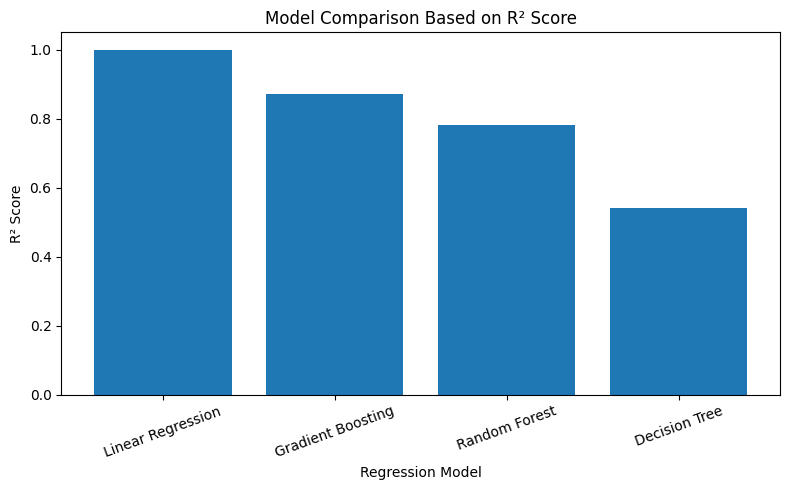

In [67]:
# VISUAL COMPARISON OF MODELS

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R² Score"])

plt.title("Model Comparison Based on R² Score")

plt.xlabel("Regression Model")

plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()


Step 21: Hyperparameter Tuning

In [72]:
# STEP 21: HYPERPARAMETER TUNING


from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Base model
rf = RandomForestRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R²:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_


Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation R²:
0.8064598529223987


Step 22: Cross Validation

In [73]:
# STEP 22: CROSS VALIDATION

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores")

print(cv_scores)

print("\nAverage R²")

print(cv_scores.mean())


Cross Validation Scores
[0.79983461 0.89044574 0.86519316 0.81348855 0.8767884 ]

Average R²
0.8491500936846512


Step 23: Feature Importance

In [74]:
# STEP 23: FEATURE IMPORTANCE

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance.head(15))


,Feature,Importance
1,Actual_Cost_Millions,0.81
5,Budget_Utilisation_Ratio,0.05
0,Planned_Budget_Millions,0.04
9,Project_Type_Infrastructure,0.03
3,Actual_Duration_Months,0.01
6,Delay_Percentage,0.01
4,Delay_Months,0.01
7,Schedule_Performance_Ratio,0.01
2,Planned_Duration_Months,0.01
17,Primary_Cause_of_Overrun_Weather Delays,0.00


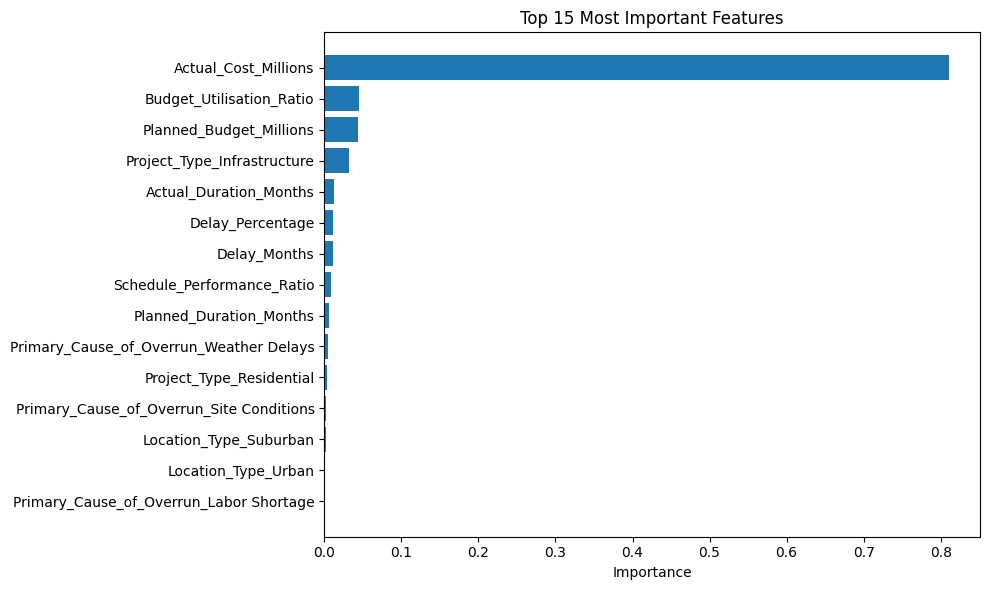

In [75]:
# Visualisation
plt.figure(figsize=(10,6))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Most Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


#### Model Interpretation

Step 24: Prediction

In [76]:
# STEP 24: PREDICTION

predictions = best_model.predict(X_test)

prediction_df = pd.DataFrame({

    "Actual Cost Overrun": y_test,

    "Predicted Cost Overrun": predictions

})

display(prediction_df.head(10))


,Actual Cost Overrun,Predicted Cost Overrun
95,8.11,3.27
15,9.14,10.68
30,4.36,3.33
158,20.84,14.79
128,2.80,1.93
115,0.53,1.23
69,36.25,37.26
170,39.85,28.00
174,38.91,39.43
45,8.13,22.38


Step 25: Final Model Evaluation

In [77]:
# STEP 25: FINAL MODEL EVALUATION

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("FINAL MODEL PERFORMANCE")

print(f"MAE  : {mae:.3f}")

print(f"MSE  : {mse:.3f}")

print(f"RMSE : {rmse:.3f}")

print(f"R²   : {r2:.3f}")


FINAL MODEL PERFORMANCE
MAE  : 4.663
MSE  : 41.080
RMSE : 6.409
R²   : 0.771


#### Model Deployment

Step 26: Save Model

In [78]:

# STEP 26: SAVE MODEL

import joblib

joblib.dump(best_model, "construction_cost_overrun_model.pkl")

joblib.dump(scaler, "construction_scaler.pkl")

print("Model saved successfully.")


Model saved successfully.


In [ ]:
# Step 27: PREDICT A NEW CONSRUCTION PROJECT
# Let use one of the projects in the dataset, PRJ-0002  

# Get the project directly from the original dataset
project = df[df["Project_ID"] == "PRJ-0002"].copy()

# Apply the same feature engineering
project["Budget_Utilisation_Ratio"] = (
    project["Planned_Budget_Millions"] /
    df["Planned_Budget_Millions"].max()
)

project["Delay_Percentage"] = (
    project["Delay_Months"] /
    project["Planned_Duration_Months"]
)

project["Schedule_Performance_Ratio"] = (
    project["Actual_Duration_Months"] /
    project["Planned_Duration_Months"]
)

# One-hot encode using the same settings
project_encoded = pd.get_dummies(project)

# Match the training columns
project_encoded = project_encoded.reindex(columns=X.columns, fill_value=0)

# Predict
prediction = best_model.predict(project_encoded)

print("Actual Cost Overrun :", project["Cost_Overrun_Millions"].values[0])
print("Predicted Overrun   :", round(prediction[0], 2))

Actual Cost Overrun : 10.84
Predicted Overrun   : 10.26


In [ ]:
# Explanation:

# Actual Cost Overrun: 10.84 million
# Predicted Cost Overrun: 10.26 million

# The prediction error is: 10.84−10.26=0.58 million

# The percentage error is: (0.58 / 10.84) * 100 = 5.35%

# A prediction within about 5% of the actual cost overrun is accepted as a good prediction for a construction project, 
# especially when it is a synthetic dataset.

#### Interpretation and Recommendation

Step 28: Business Interpretation

In [81]:

# STEP 28: BUSINESS INTERPRETATION


print("""
BUSINESS INSIGHTS

• The best machine learning model(Linear Regression) select gave us good construction cost overrun.
• A new project was test with the model as shown above and the prediction was with the acceptable error limit of 5%.
• Actual Cost Overrun: 10.84 Million, Predicted Cost Overrun: 10.26 Million

• The insights for the anaylsis will help the project managers investigate on how project delays affect cost overruns

• It assist the project manager to identify the most critical activities that if delayed could cause cost overruns.

• From the result of the prediction of the cost overrun, we can conclude that the selected model can 
  be used to support good budgeting, allocation of resources and manage risk in the construction lifecycle.

 

RECOMMENDATIONS

1. There is need to monitor closely projects that has long delay period to avoid excess cost overrrun.
2. Make constant appraisal likelihood of the project exposure to some external influence that could cause project delay or cost overrun.
3. Use last records in handling similar projects to prevent avoidable construction risk.
4. Try to introduce the predicted cost in the project management, planning and execution.
5. Often update the model with current variables, this will enhance the performance of the model
""")




BUSINESS INSIGHTS

• The best machine learning model(Linear Regression) select gave us good construction cost overrun.
• A new project was test with the model as shown above and the prediction was with the acceptable error limit of 5%.
• Actual Cost Overrun: 10.84 Million, Predicted Cost Overrun: 10.26 Million

• The insights for the anaylsis will help the project managers investigate on how project delays affect cost overruns

• It assist the project manager to identify the most critical activities that if delayed could cause cost overruns.

• From the result of the prediction of the cost overrun, we can conclude that the selected model can 
  be used to support good budgeting, allocation of resources and manage risk in the construction lifecycle.



RECOMMENDATIONS

1. There is need to monitor closely projects that has long delay period to avoid excess cost overrrun.
2. Make constant appraisal likelihood of the project exposure to some external influence that could cause project del